In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.sentiment.vader import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

import nltk
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\dania\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
news_df = pd.read_csv("../data/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../data/NVDA.csv")

In [3]:
# Convert
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce')
stock_df['Date'] = pd.to_datetime(stock_df['Date'])

news_df = news_df.dropna(subset=['date'])

In [4]:
#Filter ofr news 
nvda_news = news_df[news_df['stock'] == 'NVDA'].copy()

In [5]:
#create daily filed
nvda_news['date_only'] = nvda_news['date'].dt.date
stock_df['date_only'] = stock_df['Date'].dt.date

In [6]:
sia = SentimentIntensityAnalyzer()

nvda_news['sentiment'] = nvda_news['headline'].apply(
    lambda x: sia.polarity_scores(str(x))['compound']
)

In [7]:
nvda_news['date_only'] = nvda_news['date'].dt.date

daily_sentiment = nvda_news.groupby('date_only')['sentiment'].mean().reset_index()

In [8]:
stock_df['Date'] = pd.to_datetime(stock_df['Date'])
stock_df['date_only'] = stock_df['Date'].dt.date

stock_df = stock_df.sort_values('date_only')
stock_df['daily_return'] = stock_df['Close'].pct_change() * 100

In [9]:
#Aggregate daily senitment
daily_sentiment = (
    nvda_news
    .groupby('date_only')['sentiment']
    .mean()
    .reset_index()
)

In [10]:
#Merge dataset
merged_df = pd.merge(
    stock_df[['date_only', 'daily_return']],
    daily_sentiment,
    on='date_only',
    how='left'
)
merged_df['sentiment'] = merged_df['sentiment'].fillna(0)
merged_df = merged_df.dropna(subset=['daily_return'])

In [11]:
# Check merged data
print("Shape:", merged_df.shape)

Shape: (3773, 3)


In [12]:
#Pearson correlation
correlation, p_value = pearsonr(
    merged_df['sentiment'],
    merged_df['daily_return']
)

print("Pearson Correlation:", correlation)
print("P-value:", p_value)

Pearson Correlation: 0.016767790840255745
P-value: 0.3031562659956049


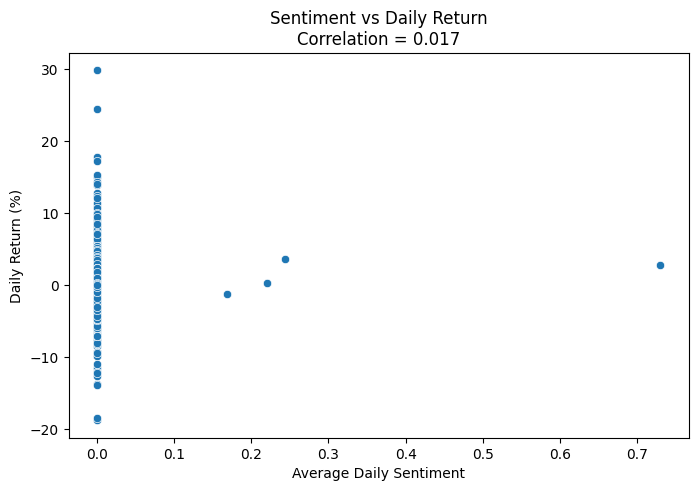

In [13]:
#scatter plot 
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=merged_df['sentiment'],
    y=merged_df['daily_return']
)

plt.title(f"Sentiment vs Daily Return\nCorrelation = {correlation:.3f}")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")

plt.show()

In [14]:
# sentimetn classification
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'
merged_df['sentiment_category'] = merged_df['sentiment'].apply(classify_sentiment)

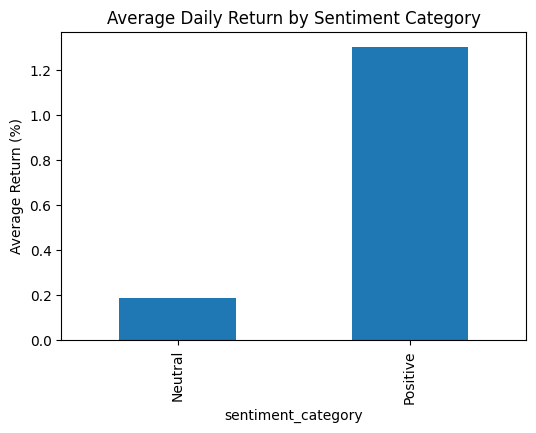

In [15]:
#barchart
avg_returns = (
    merged_df
    .groupby('sentiment_category')['daily_return']
    .mean()
)

plt.figure(figsize=(6,4))

avg_returns.plot(kind='bar')

plt.title("Average Daily Return by Sentiment Category")
plt.ylabel("Average Return (%)")

plt.show()

Across all analyzed technology stocks (AAPL, META, NVDA, and others), the Pearson correlation coefficients between daily news sentiment and stock returns were consistently weak, ranging between approximately -0.01 and 0.04. This suggests that financial news sentiment has minimal direct linear predictive power over short-term stock price movements. The results indicate that stock returns are influenced by a broader set of factors beyond headline sentiment, including macroeconomic conditions, investor behavior, and market volatilit

In [16]:
print(merged_df.shape)
print(merged_df[['sentiment','daily_return']].corr())
print(merged_df.head())

(3773, 4)
              sentiment  daily_return
sentiment      1.000000      0.016768
daily_return   0.016768      1.000000
    date_only  daily_return  sentiment sentiment_category
1  2009-01-05      1.836972        0.0            Neutral
2  2009-01-06      3.382205        0.0            Neutral
3  2009-01-07     -5.997831        0.0            Neutral
4  2009-01-08     -2.552240        0.0            Neutral
5  2009-01-09     -5.595202        0.0            Neutral
